# **1. Import dan Load Dataset**
Mengimpor library dan membaca dataset.
Pada tahap ini, dataset hipertensi dikumpulkan dan dimuat ke dalam lingkungan analisis menggunakan Python. Dataset ini berisi berbagai faktor yang berpotensi memengaruhi risiko hipertensi, seperti usia, indeks massa tubuh (BMI), tingkat stres, riwayat tekanan darah, pola olahraga, kebiasaan merokok, hingga riwayat keluarga.

Tahap ini bertujuan untuk memastikan data dapat diakses dan siap digunakan pada proses analisis berikutnya.

In [39]:
import pandas as pd
import numpy as np

!gdown --id 1m_72tM0sNV2N_hj-TAlKKHUKw-NYqb8J -O hypertension_dataset.csv
df = pd.read_csv("../data/hypertension_dataset.csv")
df.head()

'gdown' is not recognized as an internal or external command,
operable program or batch file.


,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


# **2. Data Understanding**

Sebelum melakukan analisis lebih lanjut, penting untuk memahami karakteristik dataset yang digunakan. Pada tahap ini dilakukan pemeriksaan struktur data, tipe data setiap fitur, serta statistik deskriptif untuk memperoleh gambaran awal mengenai distribusi dan kondisi data.

Pemahaman awal ini membantu dalam menentukan langkah pembersihan data, eksplorasi, serta pemilihan metode pemodelan yang tepat.
Memahami isi dataset sebelum dibersihkan.

### **2.1 Dataset Structure**
Analisis dimulai dengan melihat struktur dataset untuk mengetahui jumlah data, tipe data setiap kolom, serta keberadaan missing value. Informasi ini penting untuk menentukan proses preprocessing yang diperlukan sebelum data digunakan dalam model machine learning.

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   str    
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   str    
 7   Family_History    1985 non-null   str    
 8   Exercise_Level    1985 non-null   str    
 9   Smoking_Status    1985 non-null   str    
 10  Has_Hypertension  1985 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 239.5 KB


### **2.2 Numerical Statistics**
Selanjutnya dilakukan analisis statistik pada fitur numerik seperti usia, BMI, konsumsi garam, durasi tidur, dan tingkat stres. Statistik deskriptif memberikan gambaran mengenai rata-rata, nilai minimum, maksimum, serta penyebaran data pada setiap variabel.

In [41]:
df.describe()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


### **2.3 Categorical Statistics**
Selain fitur numerik, dataset juga memiliki beberapa fitur kategorikal seperti riwayat keluarga, status merokok, penggunaan obat, dan tingkat aktivitas fisik. Analisis ini bertujuan untuk memahami distribusi kategori yang terdapat dalam dataset.

In [42]:
df.describe(include='object')

C:\Users\INTEL i7\AppData\Local\Temp\ipykernel_32224\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,BP_History,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
count,1985,1186,1985,1985,1985,1985
unique,3,4,2,3,2,2
top,Normal,Beta Blocker,No,Low,Non-Smoker,Yes
freq,796,412,1000,936,1417,1032


# **3. Data Cleaning & Preprocessing**

Kualitas data sangat memengaruhi performa model machine learning. Oleh karena itu, sebelum dilakukan analisis lebih lanjut, dataset perlu diperiksa untuk memastikan tidak terdapat data duplikat maupun nilai yang hilang (missing value).

Tahap preprocessing dilakukan untuk menghasilkan dataset yang bersih, konsisten, dan siap digunakan pada proses analisis maupun pemodelan.

### **3.1 Cek Duplikasi**

Pemeriksaan data duplikat dilakukan untuk memastikan tidak terdapat baris data yang tercatat lebih dari satu kali. Data duplikat dapat menyebabkan bias dan memengaruhi hasil analisis maupun performa model.

In [43]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


### **3.2 Cek Missing Value**
Pemeriksaan missing value dilakukan untuk mengidentifikasi fitur yang memiliki data kosong. Visualisasi heatmap digunakan untuk mempermudah identifikasi pola missing value pada dataset.

<Axes: >

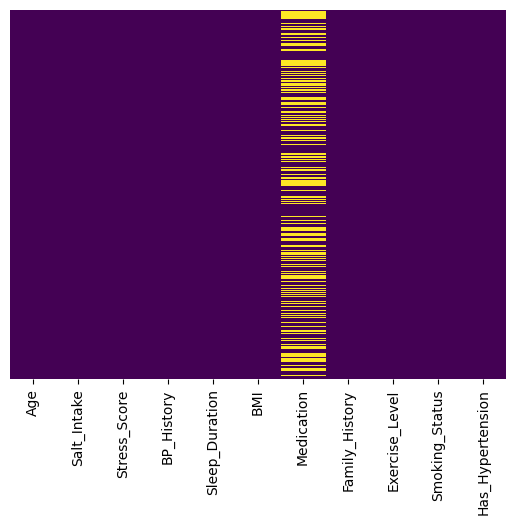

In [44]:
import seaborn as sns

df.isna().sum()
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

### **3.3 Menangani Missing Value**
Setelah ditemukan missing value pada fitur Medication, nilai kosong tersebut ditangani dengan menggantinya menjadi kategori "None". Pendekatan ini dipilih karena tidak semua responden mengonsumsi obat tertentu dan informasi tersebut tetap relevan untuk analisis.

<Axes: >

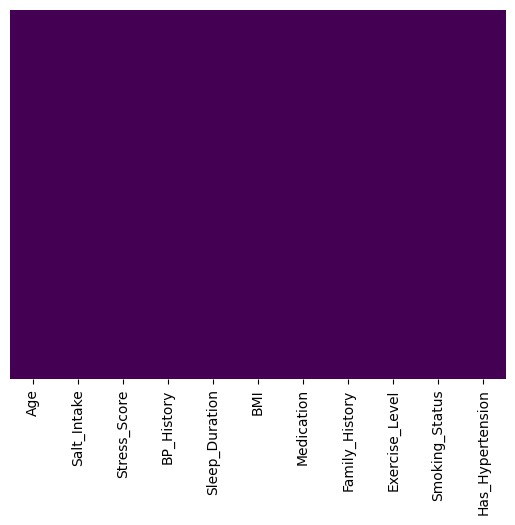

In [45]:
df['Medication'] = df['Medication'].fillna('None')

df.isna().sum()
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

# **4. Exploratory Data Analysis (EDA)**
Setelah data dibersihkan, langkah berikutnya adalah melakukan Exploratory Data Analysis (EDA). Tahap ini bertujuan untuk memahami pola, distribusi, dan hubungan antar variabel dalam dataset.

Melalui EDA, faktor-faktor yang berpotensi memengaruhi hipertensi dapat diidentifikasi sehingga memberikan insight awal sebelum pembangunan model machine learning. Mencari pola dan insight dari data.

### **4.1 Distribusi Target**
Analisis pertama dilakukan pada variabel target, yaitu Has_Hypertension. Tujuannya adalah untuk mengetahui distribusi jumlah responden yang mengalami hipertensi dan yang tidak mengalami hipertensi.

Distribusi target juga penting untuk melihat apakah dataset memiliki keseimbangan kelas yang baik untuk proses pelatihan model.

In [46]:
df['Has_Hypertension'].value_counts()

Has_Hypertension
Yes    1032
No      953
Name: count, dtype: int64

### **4.2 Distribution BMI dan Salt Intake**
Selanjutnya dilakukan analisis distribusi pada beberapa fitur numerik utama, yaitu BMI dan Salt Intake. Kedua variabel ini dipilih karena secara medis diketahui memiliki hubungan dengan risiko hipertensi.

Visualisasi boxplot digunakan untuk melihat persebaran data, nilai tengah (median), serta mendeteksi keberadaan outlier yang dapat memengaruhi analisis.

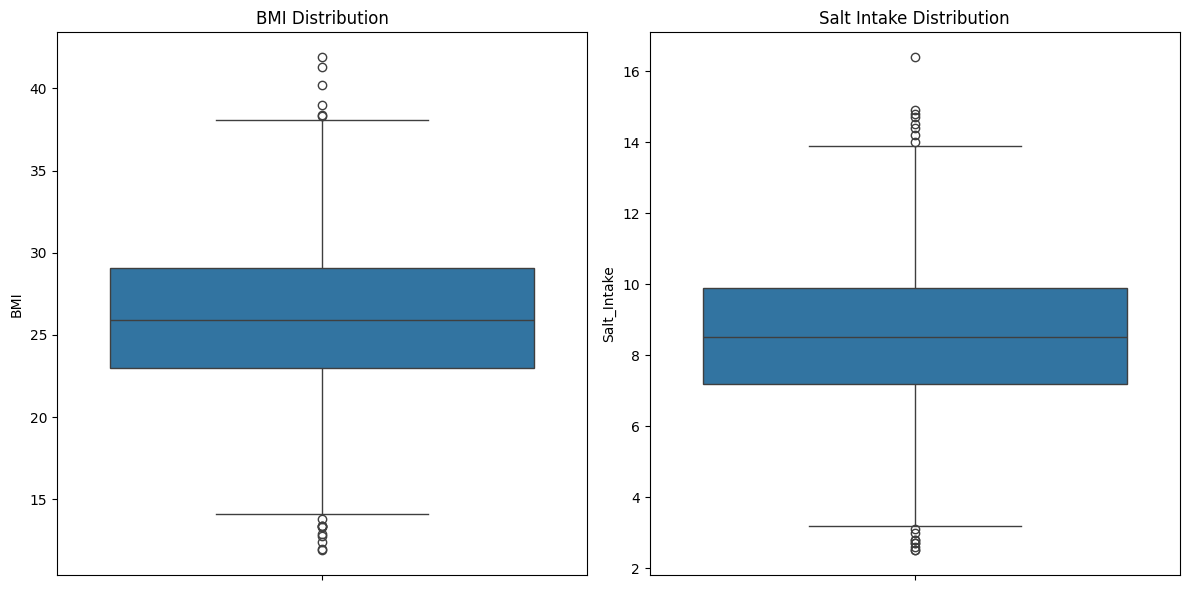

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot BMI on the first axis (axes[0])
# Note the change from x= to y= to make it vertical
sns.boxplot(y=df['BMI'], ax=axes[0])
axes[0].set_title('BMI Distribution')

# Plot Salt_Intake on the second axis (axes[1])
sns.boxplot(y=df['Salt_Intake'], ax=axes[1])
axes[1].set_title('Salt Intake Distribution')

# plt.tight_layout() ensures the labels and titles don't overlap
plt.tight_layout()
plt.show()

### **4.3 Age vs Hypertension**
Usia merupakan salah satu faktor risiko utama hipertensi. Semakin bertambah usia seseorang, elastisitas pembuluh darah cenderung menurun sehingga risiko tekanan darah tinggi dapat meningkat.

Pada analisis ini dilakukan perbandingan distribusi usia antara kelompok yang mengalami hipertensi dan yang tidak mengalami hipertensi untuk melihat apakah terdapat perbedaan karakteristik usia pada kedua kelompok tersebut.

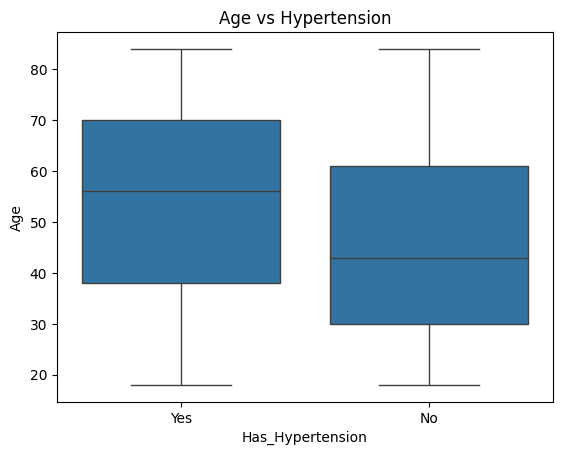

In [48]:
sns.boxplot(x='Has_Hypertension', y='Age', data=df)

plt.title("Age vs Hypertension")
plt.show()

### **4.4 BMI vs Hypertension**
Indeks Massa Tubuh (BMI) merupakan indikator yang digunakan untuk mengukur status berat badan seseorang. BMI yang tinggi sering dikaitkan dengan peningkatan risiko hipertensi.

Analisis ini dilakukan untuk melihat apakah terdapat perbedaan distribusi BMI antara kelompok hipertensi dan non-hipertensi.

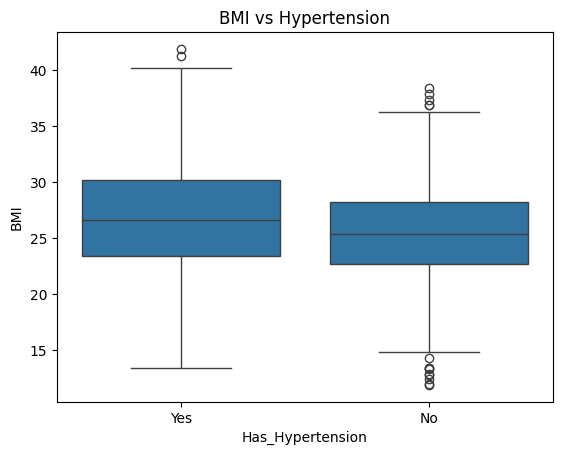

In [49]:
sns.boxplot(x='Has_Hypertension',y='BMI',data=df)

plt.title("BMI vs Hypertension")
plt.show()

### **4.5 Family History vs Hypertension**
Faktor genetik diketahui memiliki pengaruh terhadap risiko hipertensi. Individu yang memiliki anggota keluarga dengan riwayat hipertensi umumnya memiliki kemungkinan yang lebih tinggi untuk mengalami kondisi serupa.

Analisis ini dilakukan untuk melihat hubungan antara riwayat keluarga dan kejadian hipertensi pada responden.

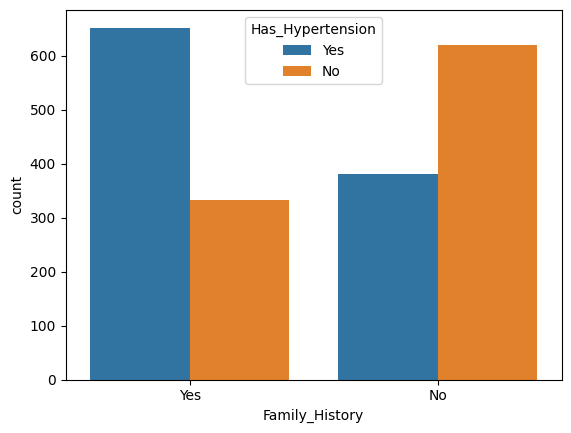

In [50]:
sns.countplot(x='Family_History',hue='Has_Hypertension',data=df)

plt.show()

### **4.6 Smoking Status vs Hypertension**
Merokok merupakan salah satu faktor gaya hidup yang dapat memengaruhi kesehatan sistem kardiovaskular. Kandungan zat kimia dalam rokok dapat menyebabkan kerusakan pembuluh darah dan meningkatkan risiko tekanan darah tinggi.

Oleh karena itu, dilakukan analisis untuk melihat distribusi hipertensi berdasarkan status merokok responden.

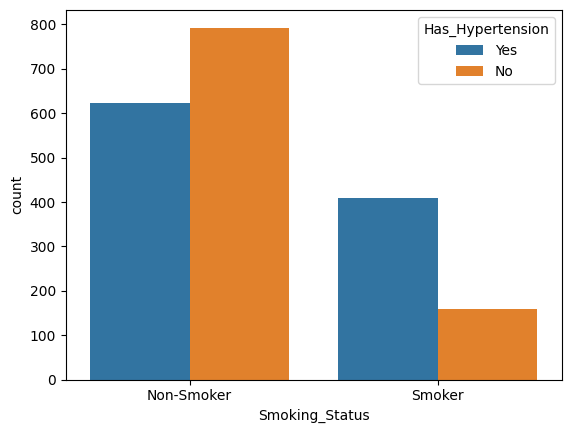

In [51]:
sns.countplot(x='Smoking_Status', hue='Has_Hypertension', data=df)

plt.show()

# **5. Feature Engineering**
Feature Engineering merupakan proses menciptakan fitur baru dari data yang sudah tersedia untuk meningkatkan kualitas analisis dan interpretasi data.

Pada penelitian ini, nilai BMI yang awalnya berbentuk angka diubah menjadi kategori berdasarkan standar kesehatan sehingga lebih mudah dipahami dan dianalisis.

### **5.1 BMI Categorization**
BMI dikategorikan menjadi empat kelompok yaitu Underweight, Normal, Overweight, dan Obese. Kategorisasi ini dilakukan berdasarkan standar klasifikasi BMI yang umum digunakan dalam bidang kesehatan.

Dengan adanya kategori BMI, hubungan antara kondisi berat badan dan hipertensi dapat dianalisis dengan lebih mudah.

In [52]:
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25.0:
        return 'Normal'
    elif 25.0 <= bmi < 30.0:
        return 'Overweight'
    else:
        return 'Obese'

# Apply the function to create a brand new column
df_clean = df.copy()
df_clean['BMI_Category'] = df_clean['BMI'].apply(categorize_bmi)

# **6. Data Encoding & Correlation Analysis**
Sebelum membangun model machine learning, seluruh fitur kategorikal perlu diubah ke dalam bentuk numerik karena algoritma machine learning tidak dapat memproses data berbentuk teks secara langsung.

Setelah proses encoding selesai, dilakukan analisis korelasi untuk mengidentifikasi hubungan antar variabel dan mengetahui faktor-faktor yang memiliki keterkaitan paling kuat terhadap hipertensi.

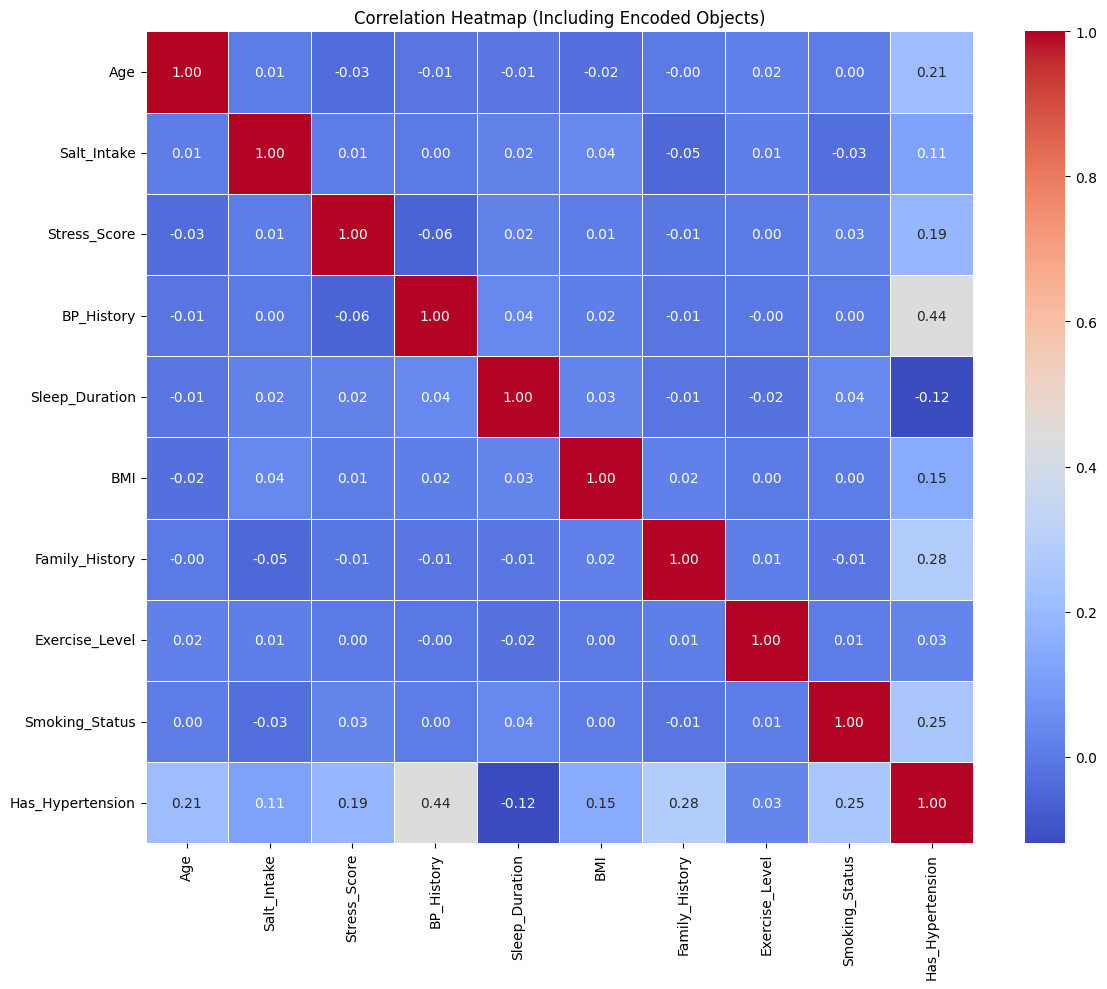

In [53]:
# 1. Create a copy of your dataframe so you don't ruin the original text data
df_encoded = df.copy()

# 2. Map the Yes/No and Ordinal columns to numbers
df_encoded['Has_Hypertension'] = df_encoded['Has_Hypertension'].map({'Yes': 1, 'No': 0})
df_encoded['Family_History'] = df_encoded['Family_History'].map({'Yes': 1, 'No': 0})
df_encoded['Exercise_Level'] = df_encoded['Exercise_Level'].map({'Low': 0, 'Moderate': 1, 'High': 2})
df_encoded['Smoking_Status'] = df_encoded['Smoking_Status'].map({'Non-Smoker': 0, 'Smoker': 1})
df_encoded['BP_History'] = df_encoded['BP_History'].map({'Normal': 0, 'Prehypertension': 1, 'Hypertension': 2})

# 3. Update your list of numerical columns to include the newly encoded ones
# Notice we are now using df_encoded!
all_numerical_cols = ['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration', 'BMI', 'Family_History', 'Exercise_Level', 'Smoking_Status', 'Has_Hypertension']

corr_matrix_full = df_encoded[all_numerical_cols].corr()

# 4. Plot the new, expanded heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_full, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Including Encoded Objects)')
plt.tight_layout()
plt.show()

# 7. Machine Learning Modeling
Tahap ini bertujuan membangun model klasifikasi yang dapat memprediksi apakah seseorang berpotensi mengalami hipertensi berdasarkan faktor-faktor kesehatan yang tersedia pada dataset.

Model yang digunakan adalah Random Forest Classifier karena memiliki performa yang baik pada data klasifikasi, mampu menangani banyak fitur sekaligus, dan relatif tahan terhadap overfitting.

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Define Features (X) and Target (y)
# Drop the Medication column (as we discussed) and the target column for X
X = df_encoded.drop(['Has_Hypertension', 'Medication'], axis=1)
y = df_encoded['Has_Hypertension']

# 2. Split the data (80% training, 20% testing)
# random_state=42 acts as a seed so you get the exact same split every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Random Forest
# n_estimators=100 means we are building a "forest" of 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make Predictions on the test set
y_pred = rf_model.predict(X_test)

# 5. Evaluate the model's performance
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 96.73%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       192
           1       0.98      0.96      0.97       205

    accuracy                           0.97       397
   macro avg       0.97      0.97      0.97       397
weighted avg       0.97      0.97      0.97       397



# 8. Model Deployment Preparation

## 8.1 Menyimpan Model Machine Learning

Setelah model Random Forest berhasil dilatih dan dievaluasi, langkah selanjutnya adalah menyimpan model tersebut agar dapat digunakan kembali tanpa perlu melakukan proses pelatihan (training) dari awal. Penyimpanan model dilakukan menggunakan library Joblib, yang mampu menyimpan objek Machine Learning ke dalam sebuah file berekstensi .pkl.

File model yang telah disimpan nantinya akan digunakan oleh aplikasi Streamlit untuk melakukan prediksi berdasarkan data yang dimasukkan oleh pengguna. Dengan demikian, proses prediksi menjadi lebih cepat karena aplikasi hanya perlu memuat model yang sudah jadi tanpa harus melatih ulang menggunakan dataset.

In [55]:
import joblib

joblib.dump(rf_model, "../models/hypertension_model.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!


# 9. Application Development (Streamlit)

Setelah model Machine Learning berhasil disimpan ke dalam file hypertension_model.pkl, tahap selanjutnya adalah mengembangkan aplikasi berbasis web menggunakan Streamlit. Proses pengembangan dilakukan dalam dua tahap, yaitu pembuatan kerangka aplikasi di Google Colab dan penyempurnaan aplikasi menggunakan Visual Studio Code (VS Code).

## 9.1 Membangun Kerangka Aplikasi di Google Colab

Pada tahap awal, Google Colab digunakan untuk membuat kerangka dasar aplikasi Streamlit. Tujuannya adalah untuk menguji apakah aplikasi dapat berjalan dengan baik sebelum dipindahkan ke lingkungan pengembangan yang lebih lengkap.

Sebelum aplikasi dijalankan, terlebih dahulu dilakukan instalasi library Streamlit beserta LocalTunnel sebagai media untuk mengakses aplikasi melalui browser.

In [56]:
# Get the Colab server's IP address (This is your Localtunnel Password!)
import urllib
print("YOUR LOCALTUNNEL PASSWORD IS:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip('\n'))

YOUR LOCALTUNNEL PASSWORD IS: 182.10.129.150


## 9.2 Membuat File Aplikasi

Setelah seluruh library berhasil diinstal, langkah berikutnya adalah membuat file utama aplikasi yaitu app.py.

In [57]:
%%writefile app.py


# =====================================================
# IMPORT LIBRARIES
# =====================================================

import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

BASE_DIR = Path(__file__).resolve().parent.parent

DATA_PATH = BASE_DIR / "data" / "hypertension_dataset.csv"
MODEL_PATH = BASE_DIR / "models" / "hypertension_model.pkl"

print(DATA_PATH)

# =====================================================
# PAGE CONFIG
# =====================================================

st.set_page_config(
    page_title="Hypertension Risk Predictor",
    page_icon="🩺",
    layout="wide"
)

# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv(DATA_PATH)

# =====================================================
# LOAD MODEL
# =====================================================

model = joblib.load(MODEL_PATH)

# =====================================================
# SIDEBAR
# =====================================================

st.sidebar.title("🩺 Navigation")

page = st.sidebar.radio(
    "Go to",
    [
        "Halaman Utama",
        "EDA Dashboard",
        "Prediction",
        "About"
    ]
)

# =====================================================
# HOME
# =====================================================

if page == "Halaman Utama":

    st.title("🩺 Hypertension Risk Prediction")

    st.markdown("""
## Deskripsi Proyek

Aplikasi ini merupakan implementasi **End-to-End Machine Learning**
yang dikembangkan untuk **GWE 2026 Data Science Challenge**.

Model Machine Learning digunakan untuk memprediksi apakah seseorang
memiliki risiko hipertensi berdasarkan kondisi kesehatan,
riwayat medis, dan gaya hidup.
""")

    st.divider()

    st.subheader("📌 Latar Belakang")

    st.write("""
Hipertensi merupakan salah satu penyakit tidak menular yang menjadi penyebab utama penyakit jantung, stroke, dan gagal ginjal.
Deteksi dini sangat penting agar pasien dapat melakukan tindakan pencegahan lebih awal.

Melalui pemanfaatan Machine Learning, proses prediksi risiko hipertensi dapat dilakukan dengan lebih cepat dan membantu proses pengambilan keputusan.
""")

    st.divider()

    st.subheader("🎯 Tujuan Proyek")

    st.write("""
- Menganalisis faktor-faktor yang memengaruhi hipertensi.
- Membangun model Machine Learning untuk memprediksi hipertensi.
- Menyediakan aplikasi berbasis Streamlit yang mudah digunakan.
""")

    st.divider()

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(
            "Total Records",
            len(df)
        )

    with col2:
        st.metric(
            "Total Features",
            len(df.columns)-1
        )

    with col3:
        st.metric(
            "Target",
            "Has_Hypertension"
        )

    st.divider()

    st.subheader("📋 Dataset Features")

    st.markdown("""
- Age
- Salt Intake
- Stress Score
- Blood Pressure History
- Sleep Duration
- BMI
- Medication
- Family History
- Exercise Level
- Smoking Status
""")

    st.divider()

    st.subheader("🧭 Navigasi Aplikasi")

    st.markdown("""
🏠 **Home**

Menampilkan informasi umum mengenai proyek.

📊 **EDA Dashboard**

Menampilkan visualisasi hasil Exploratory Data Analysis.

🔍 **Prediction**

Melakukan prediksi risiko hipertensi berdasarkan data yang dimasukkan pengguna.

ℹ️ **About**

Menampilkan informasi model, evaluasi, cara penggunaan, dan tim pengembang.
""")

    st.divider()

    st.subheader("⚙️ Project Workflow")

    st.markdown("""
1. Data Understanding

2. Data Cleaning

3. Exploratory Data Analysis (EDA)

4. Feature Encoding

5. Correlation Analysis

6. Random Forest Classification

7. Model Deployment using Streamlit
""")

# =====================================================
# EDA DASHBOARD
# =====================================================

elif page == "EDA Dashboard":

    st.title("📊 Exploratory Data Analysis")

    st.write("""
    Halaman ini menampilkan hasil Exploratory Data Analysis (EDA) untuk
    memahami karakteristik dataset serta hubungan antar variabel yang
    digunakan dalam prediksi hipertensi.
    """)

    st.divider()

    # ======================================================
    # Target Distribution
    # ======================================================

    st.subheader("Target Distribution")

    fig, ax = plt.subplots(figsize=(6,4))

    sns.countplot(
        x="Has_Hypertension",
        data=df,
        ax=ax
    )

    ax.set_title("Target Distribution")

    st.pyplot(fig)

    st.info("""
📌 **Insight:**
Grafik menunjukkan distribusi jumlah pasien yang mengalami hipertensi dan tidak mengalami hipertensi.
Visualisasi ini membantu mengetahui keseimbangan data target sebelum proses pemodelan.
""")

    st.divider()

    # ======================================================
    # BMI Distribution
    # ======================================================

    st.subheader("BMI Distribution")

    fig, ax = plt.subplots(figsize=(6,4))

    sns.boxplot(
        y=df["BMI"],
        ax=ax
    )

    ax.set_title("BMI Distribution")

    st.pyplot(fig)

    st.info("""
📌 **Insight:**
Distribusi BMI digunakan untuk melihat penyebaran nilai BMI pada seluruh data
serta mendeteksi kemungkinan adanya nilai ekstrem (outlier).
""")

    st.divider()

    # ======================================================
    # Salt Intake Distribution
    # ======================================================

    st.subheader("Salt Intake Distribution")

    fig, ax = plt.subplots(figsize=(6,4))

    sns.boxplot(
        y=df["Salt_Intake"],
        ax=ax
    )

    ax.set_title("Salt Intake Distribution")

    st.pyplot(fig)

    st.info("""
📌 **Insight:**
Grafik menunjukkan distribusi konsumsi garam pada dataset.
Perbedaan konsumsi garam dapat menjadi salah satu faktor yang berkaitan dengan risiko hipertensi.
""")

    st.divider()

    # ======================================================
    # Age vs Hypertension
    # ======================================================

    st.subheader("Age vs Hypertension")

    fig, ax = plt.subplots(figsize=(6,4))

    sns.boxplot(
        x="Has_Hypertension",
        y="Age",
        data=df,
        ax=ax
    )

    ax.set_title("Age vs Hypertension")

    st.pyplot(fig)

    st.info("""
📌 **Insight:**
Kelompok pasien dengan hipertensi cenderung memiliki usia yang lebih tinggi dibandingkan kelompok yang tidak mengalami hipertensi.
""")

    st.divider()

    # ======================================================
    # BMI vs Hypertension
    # ======================================================

    st.subheader("BMI vs Hypertension")

    fig, ax = plt.subplots(figsize=(6,4))

    sns.boxplot(
        x="Has_Hypertension",
        y="BMI",
        data=df,
        ax=ax
    )

    ax.set_title("BMI vs Hypertension")

    st.pyplot(fig)

    st.info("""
📌 **Insight:**
Pasien dengan hipertensi memiliki kecenderungan nilai BMI yang lebih tinggi,
menunjukkan adanya hubungan antara obesitas dan hipertensi.
""")

    st.divider()

    # ======================================================
    # Family History vs Hypertension
    # ======================================================

    st.subheader("Family History vs Hypertension")

    fig, ax = plt.subplots(figsize=(6,4))

    sns.countplot(
        x="Family_History",
        hue="Has_Hypertension",
        data=df,
        ax=ax
    )

    ax.set_title("Family History vs Hypertension")

    st.pyplot(fig)

    st.info("""
📌 **Insight:**
Riwayat hipertensi dalam keluarga menunjukkan hubungan dengan risiko hipertensi,
di mana individu yang memiliki riwayat keluarga cenderung lebih berisiko.
""")

    st.divider()

    # ======================================================
    # Smoking Status vs Hypertension
    # ======================================================

    st.subheader("Smoking Status vs Hypertension")

    fig, ax = plt.subplots(figsize=(6,4))

    sns.countplot(
        x="Smoking_Status",
        hue="Has_Hypertension",
        data=df,
        ax=ax
    )

    ax.set_title("Smoking Status vs Hypertension")

    st.pyplot(fig)

    st.info("""
📌 **Insight:**
Grafik membandingkan status merokok dengan kondisi hipertensi.
Kebiasaan merokok dapat menjadi salah satu faktor yang memengaruhi risiko hipertensi.
""")

    st.divider()

    # ======================================================
    # Correlation Heatmap
    # ======================================================

    st.subheader("Correlation Heatmap")

    df_encoded = df.copy()

    df_encoded["Has_Hypertension"] = df_encoded["Has_Hypertension"].map({"Yes":1,"No":0})
    df_encoded["Family_History"] = df_encoded["Family_History"].map({"Yes":1,"No":0})
    df_encoded["Exercise_Level"] = df_encoded["Exercise_Level"].map({"Low":0,"Moderate":1,"High":2})
    df_encoded["Smoking_Status"] = df_encoded["Smoking_Status"].map({"Non-Smoker":0,"Smoker":1})
    df_encoded["BP_History"] = df_encoded["BP_History"].map({"Normal":0,"Prehypertension":1,"Hypertension":2})

    numerical_cols = [
        "Age",
        "Salt_Intake",
        "Stress_Score",
        "BP_History",
        "Sleep_Duration",
        "BMI",
        "Family_History",
        "Exercise_Level",
        "Smoking_Status",
        "Has_Hypertension"
    ]

    corr = df_encoded[numerical_cols].corr()

    fig, ax = plt.subplots(figsize=(10,8))

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        ax=ax
    )

    ax.set_title("Correlation Heatmap")

    st.pyplot(fig)

    st.info("""
📌 **Insight:**
Heatmap digunakan untuk melihat hubungan antar variabel.
Semakin mendekati nilai 1 atau -1 menunjukkan hubungan yang semakin kuat,
sedangkan nilai yang mendekati 0 menunjukkan hubungan yang lemah.
""")

    st.divider()

    st.subheader("📌 Kesimpulan EDA")

    st.success("""
Berdasarkan hasil Exploratory Data Analysis (EDA), variabel seperti usia, BMI,
riwayat keluarga, dan status merokok menunjukkan hubungan terhadap risiko hipertensi.
Hasil analisis ini menjadi dasar dalam pembangunan model Machine Learning untuk memprediksi hipertensi.
""")

# =====================================================
# PREDICTION
# =====================================================

elif page == "Prediction":

    st.title("🤖 Hypertension Risk Prediction")

    st.write(
        "Enter the patient's information below."
    )

    st.divider()

    col1, col2 = st.columns(2)

    with col1:

        age = st.number_input(
            "Age",
            min_value=1,
            max_value=120,
            value=25
        )

        salt = st.number_input(
            "Salt Intake",
            min_value=0.0,
            max_value=20.0,
            value=5.0
        )

        stress = st.number_input(
            "Stress Score",
            min_value=0,
            max_value=100,
            value=50
        )

        bp = st.selectbox(
            "Blood Pressure History",
            [
                "Normal",
                "Prehypertension",
                "Hypertension"
            ]
        )

        sleep = st.number_input(
            "Sleep Duration",
            min_value=0.0,
            max_value=24.0,
            value=7.0
        )

    with col2:

        bmi = st.number_input(
            "BMI",
            min_value=10.0,
            max_value=60.0,
            value=22.0
        )

        family = st.selectbox(
            "Family History",
            [
                "No",
                "Yes"
            ]
        )

        exercise = st.selectbox(
            "Exercise Level",
            [
                "Low",
                "Moderate",
                "High"
            ]
        )

        smoking = st.selectbox(
            "Smoking Status",
            [
                "Non-Smoker",
                "Smoker"
            ]
        )

    st.divider()

    if st.button("Predict"):

# ==========================================
# Encoding (Sama seperti notebook)
# ==========================================

        bp_value = {
            "Normal": 0,
            "Prehypertension": 1,
            "Hypertension": 2
        }[bp]

        family_value = {
            "No": 0,
            "Yes": 1
        }[family]

        exercise_value = {
            "Low": 0,
            "Moderate": 1,
            "High": 2
        }[exercise]

        smoking_value = {
            "Non-Smoker": 0,
            "Smoker": 1
        }[smoking]

        # ==========================================
        # Create DataFrame
        # ==========================================

        input_data = pd.DataFrame({

            "Age":[age],
            "Salt_Intake":[salt],
            "Stress_Score":[stress],
            "BP_History":[bp_value],
            "Sleep_Duration":[sleep],
            "BMI":[bmi],
            "Family_History":[family_value],
            "Exercise_Level":[exercise_value],
            "Smoking_Status":[smoking_value]

        })

        # ==========================================
        # Prediction
        # ==========================================

        prediction = model.predict(input_data)

        probability = model.predict_proba(input_data)

        confidence = probability[0].max() * 100

        st.divider()

        st.subheader("Prediction Result")

        if prediction[0] == 1:

            st.error("⚠️ High Risk of Hypertension")

        else:

            st.success("✅ Low Risk of Hypertension")

        st.metric(
            label="Model Confidence",
            value=f"{confidence:.2f}%"
        )

        st.divider()

        st.subheader("Input Summary")

        summary = pd.DataFrame({

            "Feature":[
                "Age",
                "Salt Intake",
                "Stress Score",
                "Blood Pressure History",
                "Sleep Duration",
                "BMI",
                "Family History",
                "Exercise Level",
                "Smoking Status"
            ],

            "Value":[
                age,
                salt,
                stress,
                bp,
                sleep,
                bmi,
                family,
                exercise,
                smoking
            ]

        })

        st.dataframe(summary, use_container_width=True)

# =====================================================
# ABOUT
# =====================================================

elif page == "About":

    st.title("ℹ️ About This Project")

    st.markdown("""
### Hypertension Risk Prediction

Aplikasi ini dikembangkan sebagai proyek **End-to-End Machine Learning**
untuk **GWE 2026 Data Science Challenge**.

Tujuan aplikasi adalah memprediksi risiko hipertensi berdasarkan
karakteristik kesehatan dan gaya hidup pasien.
""")

    st.divider()

    st.subheader("🤖 Machine Learning Model")

    st.write("""
Model yang digunakan adalah **Random Forest Classifier**.

Random Forest dipilih karena memiliki performa yang baik,
mampu menangani data numerik maupun kategorikal,
serta cukup stabil dalam proses klasifikasi.
""")

    st.divider()

    st.subheader("📈 Evaluation Metrics")

    st.write("""
Accuracy : **96.73%**

Precision : **0.97**

Recall : **0.97**

F1-Score : **0.97**
""")

    st.divider()

    st.subheader("📂 Dataset Features")

    st.write("""
- Age
- Salt Intake
- Stress Score
- Blood Pressure History
- Sleep Duration
- BMI
- Family History
- Exercise Level
- Smoking Status
""")

    st.divider()

    st.subheader("⚙️ Project Workflow")

    st.write("""
✔ Data Understanding

✔ Data Cleaning

✔ Exploratory Data Analysis

✔ Feature Encoding

✔ Correlation Analysis

✔ Random Forest Classification

✔ Deployment using Streamlit
""")

    st.divider()

    st.subheader("📝 Cara Menggunakan Aplikasi")

    st.write("""
1. Pilih menu **Prediction**.
2. Masukkan seluruh data pasien.
3. Klik tombol **Predict**.
4. Sistem akan menampilkan hasil prediksi hipertensi beserta probabilitasnya.
""")

    st.divider()

    st.subheader("👥 Team")

    st.write("""
**Naufal Asa Malika**  (103012500151)

**Muhammad Zubair**  (102022500261)
""")

    st.success("Terima kasih telah menggunakan aplikasi kami!")

Writing app.py


# 10. Kesimpulan

Pada proyek ini telah berhasil dibangun model Machine Learning menggunakan algoritma Random Forest untuk memprediksi risiko hipertensi berdasarkan data kesehatan. Proses yang dilakukan meliputi Exploratory Data Analysis (EDA), data preprocessing, pelatihan model, hingga evaluasi performa model.

Hasil evaluasi menunjukkan bahwa model memiliki akurasi sebesar 96,73%, sehingga mampu memberikan prediksi dengan performa yang baik. Model tersebut kemudian diimplementasikan ke dalam aplikasi berbasis Streamlit sehingga pengguna dapat melakukan prediksi risiko hipertensi secara lebih mudah melalui antarmuka yang interaktif.

Secara keseluruhan, proyek ini menunjukkan bahwa penerapan machine learning dapat dimanfaatkan sebagai alat bantu dalam memprediksi risiko hipertensi, meskipun hasil prediksi tetap tidak dapat menggantikan diagnosis dari tenaga medis profesional.